In [1]:
# Useful for debugging
%load_ext autoreload
%autoreload 2

In [2]:
from impact import Impact

from distgen import Generator

import numpy as np

import os 

ROOT = os.environ['LCLS_LATTICE']

In [3]:
# Nicer plotting
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
matplotlib.rcParams['figure.figsize'] = (8,4)

# cu_inj Impact-T

In [4]:
ifile = os.path.join(ROOT, 'impact/models/cu_inj/v0/ImpactT.yaml')
gfile = os.path.join(ROOT, 'distgen/models/cu_inj/v0/distgen.yaml')
assert os.path.exists(ifile)
assert os.path.exists(gfile)


In [5]:
I = Impact.from_yaml(ifile)

In [6]:
ele = I.ele['L0A_body_1']
ele['zedge'] + ele['L']/2

3.0064279999999997

In [7]:
2.579826 - 3.006428

-0.4266019999999999

In [8]:
6.408275 - 6.850184

-0.4419089999999999

In [9]:
ele = I.ele['L0B_body_1']
ele['zedge'] + ele['L']/2

6.850184

In [10]:
klist =  ['QA01:b1_gradient',
 'QA02:b1_gradient',
 'QE01:b1_gradient',
 'QE02:b1_gradient',
 'QE03:b1_gradient',
 'QE04:b1_gradient']
for k in klist:
    print(k, I[k])

QA01:b1_gradient 1.8524000101358
QA02:b1_gradient -1.8524000101358
QE01:b1_gradient 0.18720000156206
QE02:b1_gradient 0.16609999999321
QE03:b1_gradient -2.6409000012747
QE04:b1_gradient 2.9799999853198


In [8]:
I.track1()

<ParticleGroup with 1 particles at 0x15f3a3190>

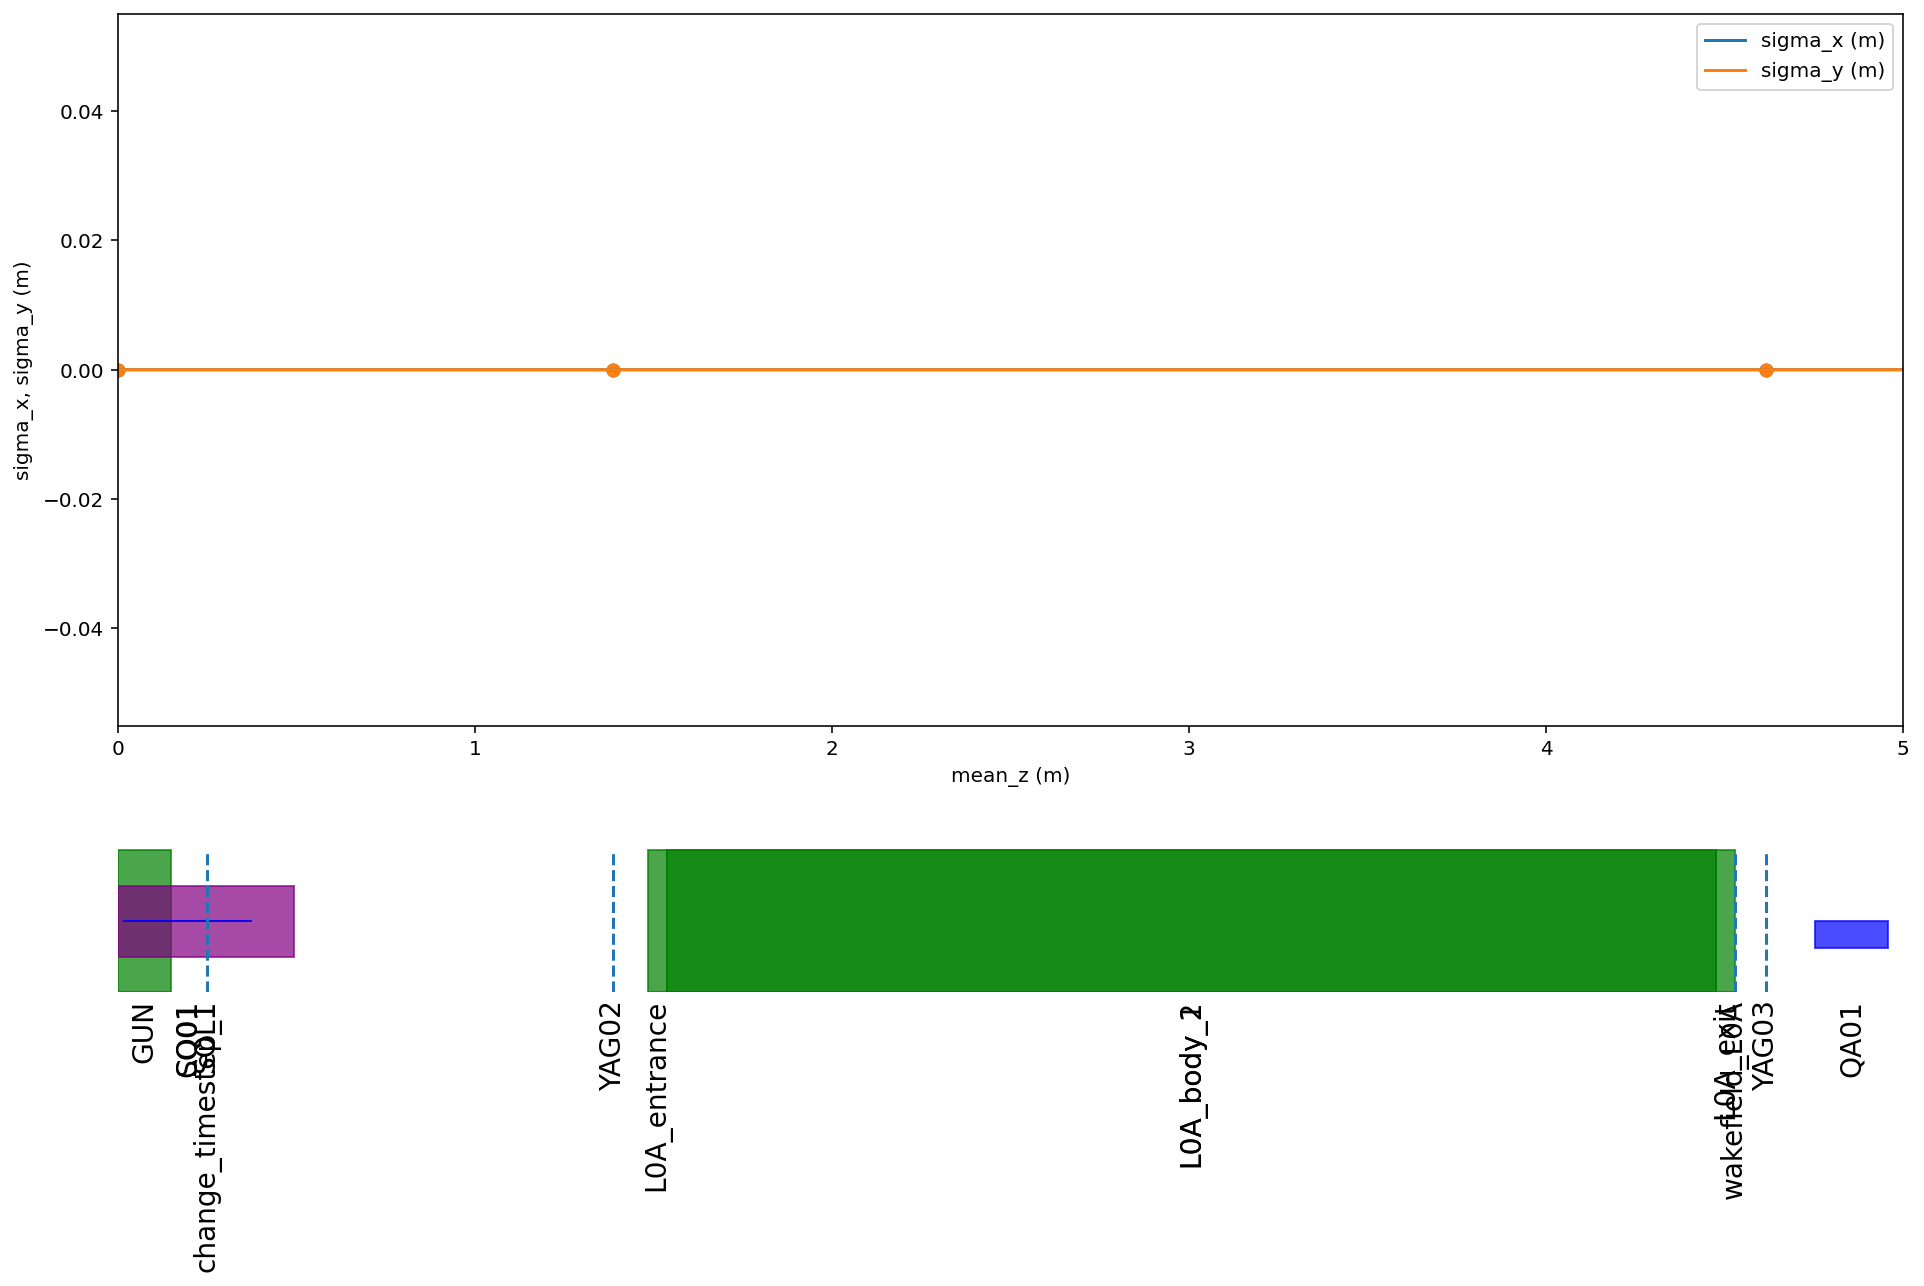

In [9]:
fig = I.plot(return_figure=True, include_labels=True, xlim=(0,5), figsize=(16,9))

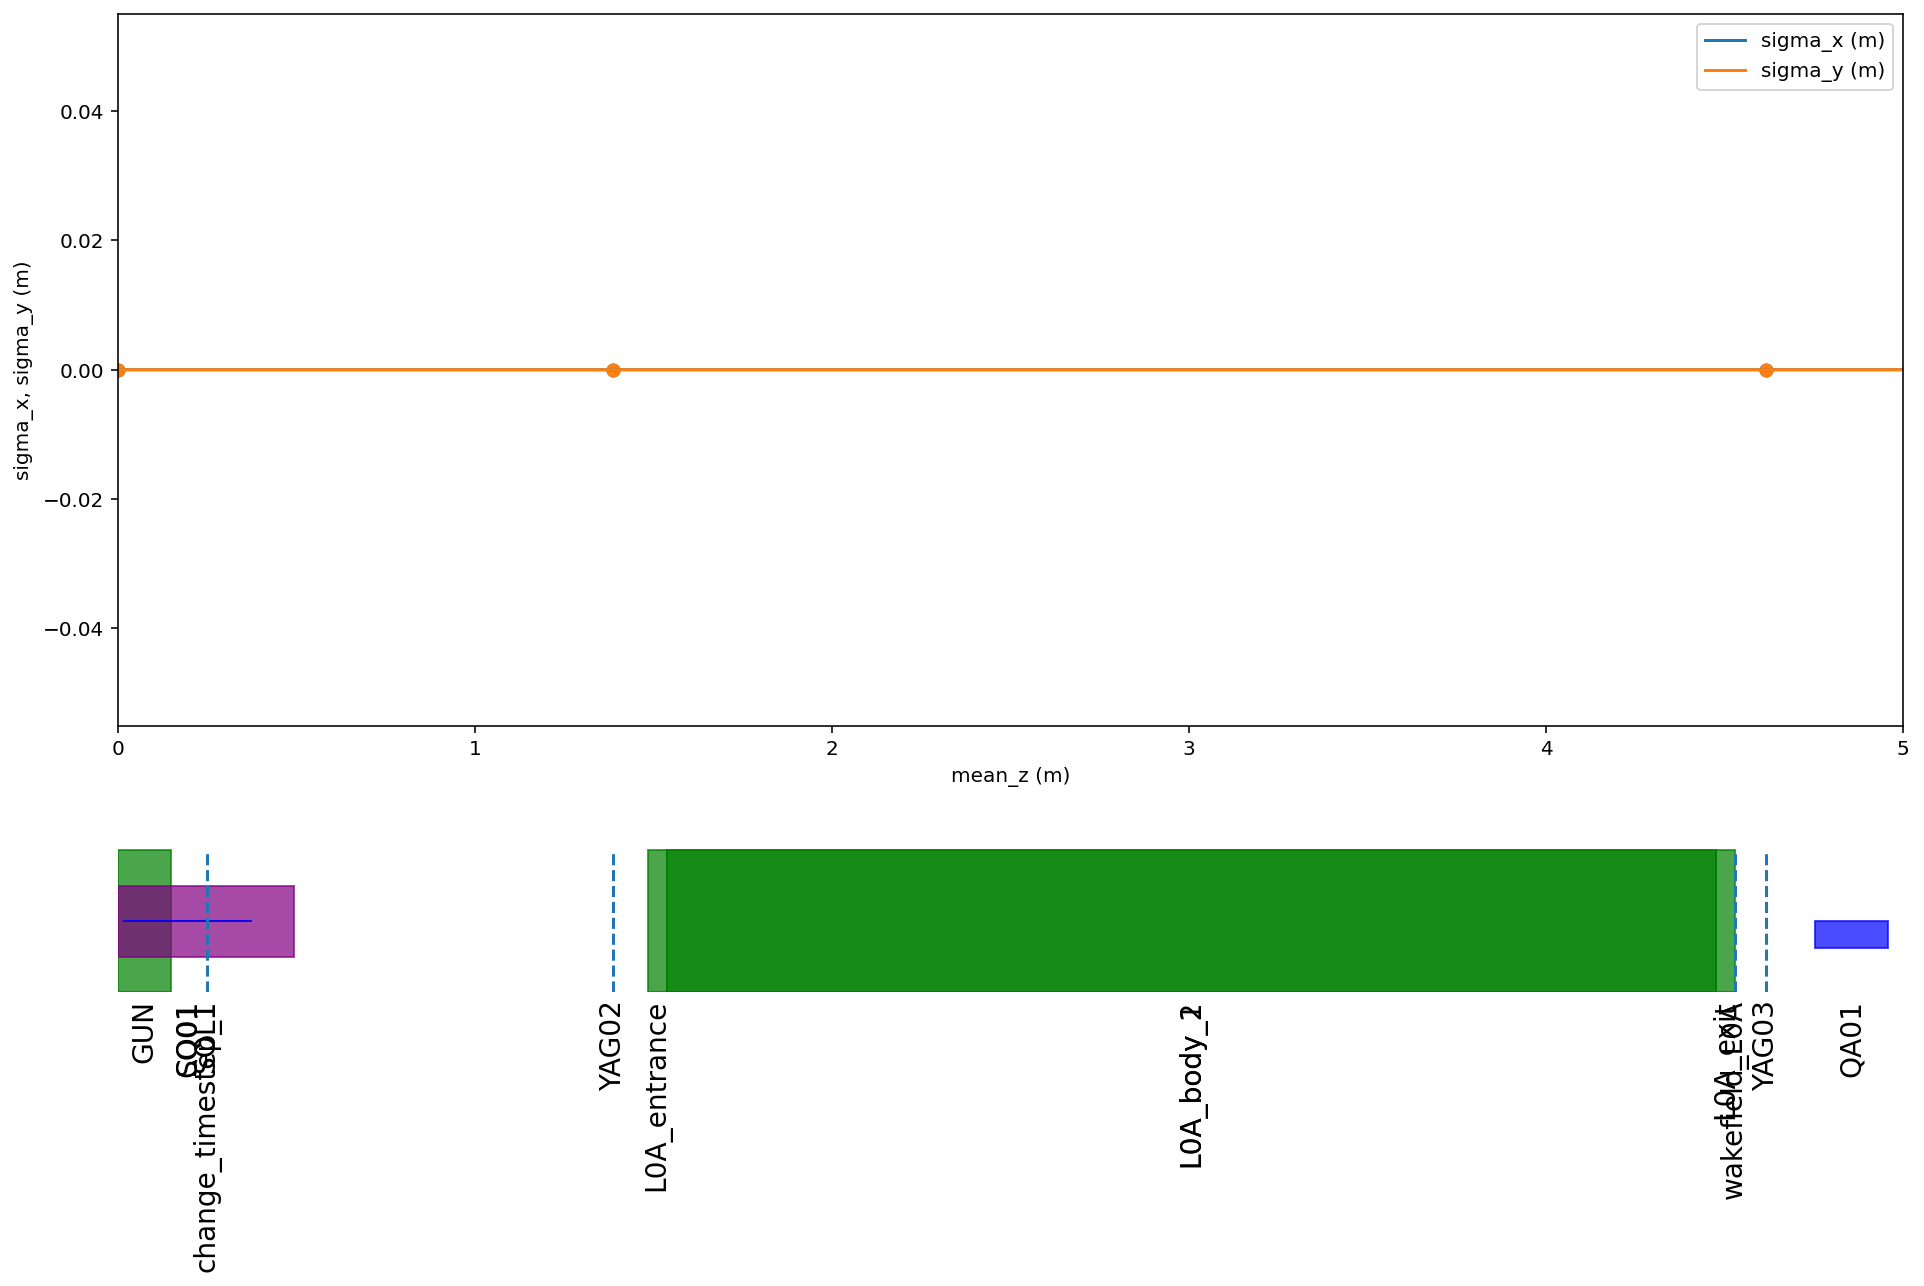

In [9]:
fig 

In [10]:
fig.savefig('test.pdf')

In [11]:
plt.show()

In [12]:
I['L0A_phase']['dtheta0_deg'] = 0

In [13]:
I['L0A_entrance']

{'description': 'name:L0A_entrance',
 'original': '0.052464 0 0 105 1.485 26013438.73067529 2856000000.0 267.5 4 0.15 0.0 0.0 0.0 0.0 0.0 0.0 /!name:L0A_entrance',
 'L': 0.052464,
 'type': 'solrf',
 'zedge': 1.485,
 'rf_field_scale': 26013439.060000002,
 'rf_frequency': 2856000000.0,
 'theta0_deg': 267.5,
 'filename': 'rfdata4',
 'radius': 0.15,
 'x_offset': 0.0,
 'y_offset': 0.0,
 'x_rotation': 0.0,
 'y_rotation': 0.0,
 'z_rotation': 0.0,
 'solenoid_field_scale': 0.0,
 's': 1.5374640000000002,
 'name': 'L0A_entrance'}

In [14]:
for ele in I.lattice:
    if ele['type'] != 'quadrupole':
        continue
    name = ele['name']
    L = ele['L']
    L_eff = ele['L_effective']
    zedge = ele['zedge']
    sbeg = zedge + (L-L_eff)/2
    send = zedge + L - (L-L_eff)/2
    offset = 2017.91148
    print(f'{name} {L:10} {L_eff:10} {sbeg:10.6} {send:10.6}')

SQ01       0.36       0.21    0.09101    0.30101
CQ01       0.36       0.21    0.09101    0.30101
QA01      0.204      0.108    4.80093    4.90893
QA02      0.204      0.108    5.12931    5.23731
QE01      0.204      0.108    8.44005    8.54805
QE02      0.204      0.108    8.84156    8.94956
QE03      0.204      0.108    11.5172    11.6252
QE04      0.204      0.108    11.9236    12.0316


In [15]:
from impact.lattice import ele_line
ele_line(I.lattice[-1])

'0 0 0 -99 16.5 0.0 16.5 /!name:stop_1'

# Check Energies

In [16]:
from impact.autophase import autophase_and_scale

from pmd_beamphysics import single_particle

P0 = single_particle(pz=1e-15, z=1e-15)

# Energy out of the gun
I.track(P0, s = 0.5)['mean_energy']

6000004.19148926

In [17]:
I.track(P0, s = I['L0A_exit']['s'])['mean_energy']

63999929.1840505

In [18]:
I.track(P0, s = I['OTR2']['s'])['mean_energy']

134004573.62034492

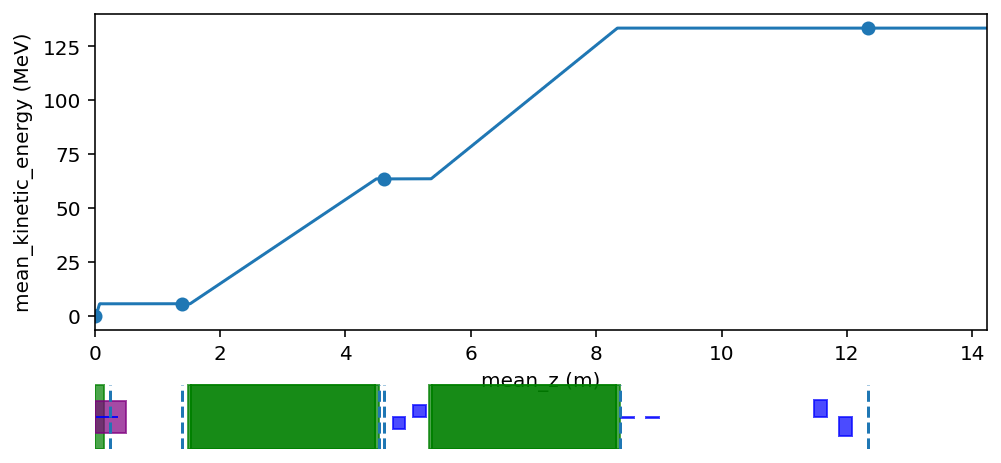

In [19]:
I.plot('mean_kinetic_energy')

In [20]:
I.particles

{'initial_particles': <ParticleGroup with 1 particles at 0x1627c78e0>,
 'final_particles': <ParticleGroup with 1 particles at 0x10c609e80>,
 'YAG02': <ParticleGroup with 1 particles at 0x16580f0a0>,
 'YAG03': <ParticleGroup with 1 particles at 0x1633117c0>,
 'OTR1': <ParticleGroup with 1 particles at 0x163311640>,
 'OTR2': <ParticleGroup with 1 particles at 0x163311460>}

# Gun Phasing

In [21]:
autophase_and_scale(I, phase_ele_name='GUN_phase', phase_attribute='dtheta0_deg', scale_ele_name='GUN_scale', scale_attribute='voltage', target=6e6, scale_range=(4e6, 6e6), metric='mean_energy', initial_particles=P0, verbose=True)

Copied initial Impact object. 
Phasing GUN_phase by changing dtheta0_deg
Scaling GUN_scale by changing voltage
Bounds: 0.0, 0.15 m
Disabling SOL1
Disabling L0A_entrance
Disabling L0A_body_1
Disabling L0A_body_2
Disabling L0A_exit
Disabling L0B_entrance
Disabling L0B_body_1
Disabling L0B_body_2
Disabling L0B_exit
Default brent2 algorithm
Phase: 180, Scale: 4000000.0, 0.0 M
Phase: 180, Scale: 4000000.0, 0.0 M
Phase: 42.49224000000004, Scale: 4000000.0, 3.318758635965434 MeV
Phase: 264.9844890561601, Scale: 4000000.0, 0.0 M
Phase: 42.49224000000004, Scale: 4000000.0, 3.318758635965434 MeV
Phase: 42.49223440298533, Scale: 4000000.0, 3.318758936008975 MeV
Phase: 264.9844709438398, Scale: 4000000.0, 0.0 M
Phase: 222.49225347499612, Scale: 4000000.0, 0.0 M
Phase: 127.47670402554945, Scale: 4000000.0, 0.0 M
Phase: 333.7383616878451, Scale: 4000000.0, 4.431646046438251 MeV
Phase: 291.246130718216, Scale: 4000000.0, 0.0 M
Phase: 3.433356368987006e-06, Scale: 4000000.0, 4.466520028829678 MeV
Phas

(0.0779591774616506, 5489001.168563953)

# L0A, L0B

In [22]:
# L0A
autophase_and_scale(I, phase_ele_name='L0A_phase', phase_attribute='dtheta0_deg', scale_ele_name='L0A_scale', scale_attribute='voltage',
                    target=64e6, scale_range=(10e6, 100e6), initial_particles=P0, verbose=True, debug=False)

Copied initial Impact object. 
Phasing L0A_phase by changing dtheta0_deg
Scaling L0A_scale by changing voltage
Bounds: 1.485, 4.527856 m
Tracking initial particles to s = 1.485
Initial particle:  1.48506834668 6000000.000077931
Disabling GUN
Disabling SOL1
Disabling L0B_entrance
Disabling L0B_body_1
Disabling L0B_body_2
Disabling L0B_exit
Default brent2 algorithm
Phase: 180, Scale: 10000000.0, 5.671561509900464 MeV
Phase: 180, Scale: 10000000.0, 5.671561509900464 MeV
Phase: 42.49224000000004, Scale: 10000000.0, 12.368939525707741 MeV
Phase: 264.9844890561601, Scale: 10000000.0, 7.737546690120944 MeV
Phase: 42.49224000000004, Scale: 10000000.0, 12.368939525707741 MeV
Phase: 42.49223440298533, Scale: 10000000.0, 12.368940337665192 MeV
Phase: 264.9844709438398, Scale: 10000000.0, 7.737544479546379 MeV
Phase: 222.4922687583561, Scale: 10000000.0, 4.761755118040896 MeV
Phase: 127.47670402554945, Scale: 10000000.0, 4.123913380014113 MeV
Phase: 333.73836752556895, Scale: 10000000.0, 15.404734

(0.01340187843845797, 57999993.6793238)

In [23]:
ps_f, Itest = autophase_and_scale(I, phase_ele_name='L0A_phase', phase_attribute='dtheta0_deg', scale_ele_name='L0A_scale', scale_attribute='voltage',
                    target=64e6, scale_range=(10e6, 100e6), initial_particles=P0, verbose=True, debug=True)

Copied initial Impact object. 
Phasing L0A_phase by changing dtheta0_deg
Scaling L0A_scale by changing voltage
Bounds: 1.485, 4.527856 m
Tracking initial particles to s = 1.485
Initial particle:  1.48506834668 6000000.000077931
Disabling GUN
Disabling SOL1
Disabling L0B_entrance
Disabling L0B_body_1
Disabling L0B_body_2
Disabling L0B_exit


Phase: -2.0, Scale: 58000000.0, 63.964903284591244 MeV
Phase: -1.5, Scale: 58000000.0, 63.98026113625154 MeV
Phase: -1.0, Scale: 58000000.0, 63.991233363175056 MeV
Phase: -0.5, Scale: 58000000.0, 63.997814461869396 MeV
Phase: 0.0, Scale: 58000000.0, 63.999999263086345 MeV
Phase: 0.5, Scale: 58000000.0, 63.997782932333 MeV
Phase: 1.0, Scale: 58000000.0, 63.99116096936098 MeV
Phase: 1.5, Scale: 58000000.0, 63.98012920407874 MeV
Phase: 2.0, Scale: 58000000.0, 63.96468379859574 MeV


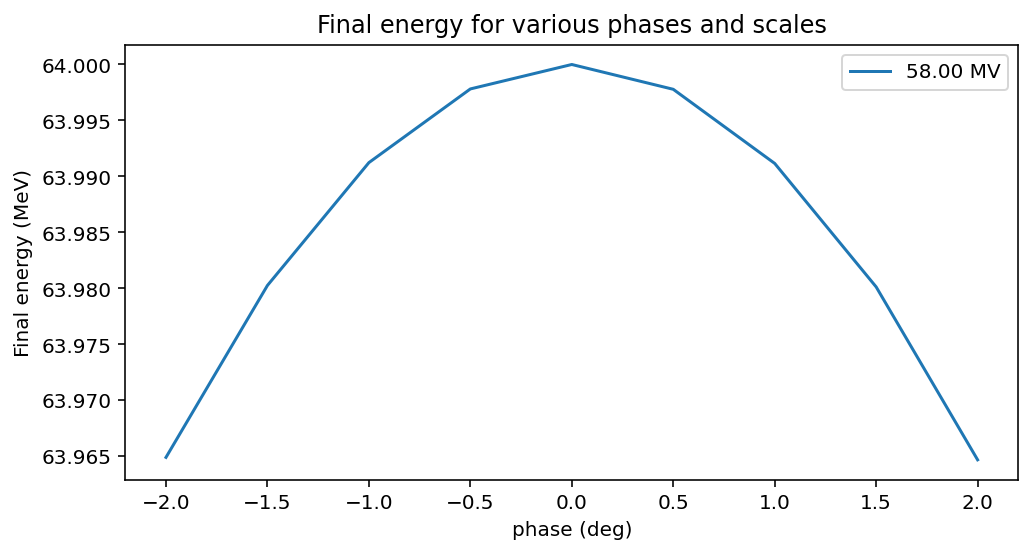

In [24]:
# Phases to try
ptry = np.linspace(-2, 2, 9)

# scales to try
sc = 58e6
res = np.array([ps_f(p, sc)/1e6 for p in ptry])
plt.plot(ptry, res, label=f'{sc/1e6:0.2f} MV')
plt.title('Final energy for various phases and scales')
plt.ylabel('Final energy (MeV)')
plt.xlabel('phase (deg)')
plt.legend()

In [25]:
# Get scale/voltage factor
30048347.359377533/(64e6 - 6e6) * np.array( [0.86571945106805, 1, 1, 0.86571945106805])

array([0.44850757, 0.51807495, 0.51807495, 0.44850757])

In [26]:
I = Impact.from_yaml(ifile)
I.group['L0B_scale']

ControlGroup(**{"ele_names": ["L0B_entrance", "L0B_body_1", "L0B_body_2", "L0B_exit"], "var_name": "voltage", "attributes": ["rf_field_scale", "rf_field_scale", "rf_field_scale", "rf_field_scale"], "factors": [0.44850757, 0.51807495, 0.51807495, 0.44850757], "reference_values": [31841617.97938928, 36780527.3869102, 36780527.3869102, 31841617.97938928], "absolute": true, "value": 70000000.0})

In [27]:
f, I0 = autophase_and_scale(I, phase_ele_name='L0B_phase', phase_attribute='dtheta0_deg', scale_ele_name='L0B_scale', scale_attribute='voltage', target=135e6, scale_range=(10e6, 100e6), initial_particles=P0, verbose=True, debug=True)

Copied initial Impact object. 
Phasing L0B_phase by changing dtheta0_deg
Scaling L0B_scale by changing voltage
Bounds: 5.328756, 8.371612 m
Tracking initial particles to s = 5.328756
Initial particle:  5.32873235036 63919483.38313114
Disabling GUN
Disabling SOL1
Disabling L0A_entrance
Disabling L0A_body_1
Disabling L0A_body_2
Disabling L0A_exit


In [28]:
f(0, 0)

Phase: 0, Scale: 0, 63.92024011289627 MeV


63920240.11289627

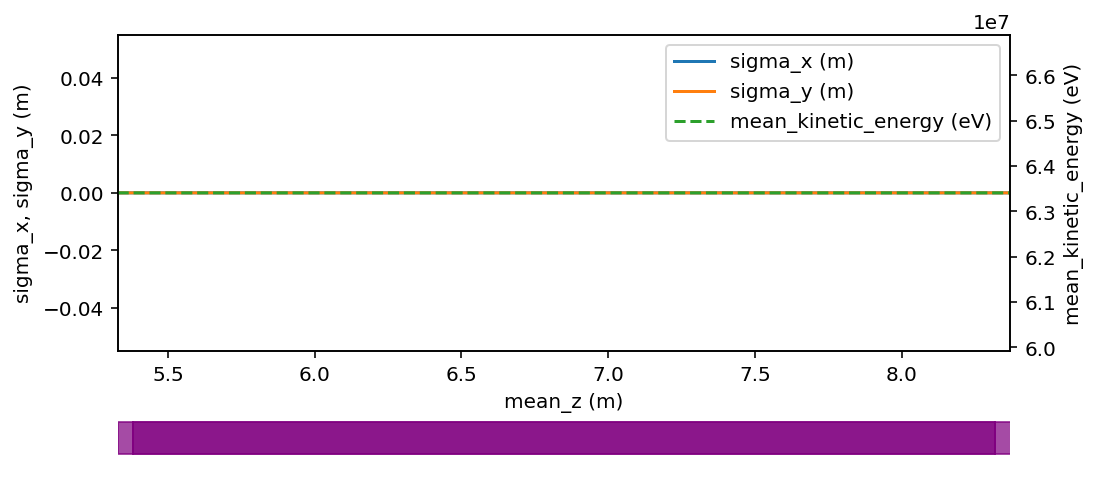

In [29]:
I0.plot(y2='mean_kinetic_energy')

In [30]:
I0.group['L0B_scale']

ControlGroup(**{"ele_names": ["L0B_entrance", "L0B_body_1", "L0B_body_2", "L0B_exit"], "var_name": "voltage", "attributes": ["rf_field_scale", "rf_field_scale", "rf_field_scale", "rf_field_scale"], "factors": [0.44850757, 0.51807495, 0.51807495, 0.44850757], "reference_values": [31841617.97938928, 36780527.3869102, 36780527.3869102, 31841617.97938928], "absolute": true, "value": 0})

In [31]:
I0.group['L0B_scale'].ele_names

['L0B_entrance', 'L0B_body_1', 'L0B_body_2', 'L0B_exit']

In [32]:
I0['L0B_body_1']

{'description': 'name:L0B_body_1',
 'original': '2.937928 0 0 105 5.38122  36780527.3869102 2856000000.0  74.27 5 0.15 0.0 0.0 0.0 0.0 0.0 0.0 /!name:L0B_body_1',
 'L': 2.937928,
 'type': 'solrf',
 'zedge': 5.38122,
 'rf_field_scale': 0.0,
 'rf_frequency': 2856000000.0,
 'theta0_deg': 74.27,
 'filename': 'rfdata5',
 'radius': 0.15,
 'x_offset': 0.0,
 'y_offset': 0.0,
 'x_rotation': 0.0,
 'y_rotation': 0.0,
 'z_rotation': 0.0,
 'solenoid_field_scale': 0.0,
 's': 8.319148,
 'name': 'L0B_body_1'}

In [33]:
f(2.9964116947667208e-06, 10e6)

Phase: 2.9964116947667208e-06, Scale: 10000000.0, 73.92096199502403 MeV


73920961.99502403

In [34]:
autophase_and_scale(I, phase_ele_name='L0B_phase', phase_attribute='dtheta0_deg', scale_ele_name='L0B_scale', scale_attribute='voltage', target=135e6, scale_range=(10e6, 100e6), initial_particles=P0, verbose=True)

Copied initial Impact object. 
Phasing L0B_phase by changing dtheta0_deg
Scaling L0B_scale by changing voltage
Bounds: 5.328756, 8.371612 m
Tracking initial particles to s = 5.328756
Initial particle:  5.32873235036 63919483.38313114
Disabling GUN
Disabling SOL1
Disabling L0A_entrance
Disabling L0A_body_1
Disabling L0A_body_2
Disabling L0A_exit
Default brent2 algorithm
Phase: 180, Scale: 10000000.0, 53.91948397017891 MeV
Phase: 180, Scale: 10000000.0, 53.91948397017891 MeV
Phase: 42.49224000000004, Scale: 10000000.0, 71.2879726950974 MeV
Phase: 264.9844890561601, Scale: 10000000.0, 63.05772380591201 MeV
Phase: 42.49224000000004, Scale: 10000000.0, 71.2879726950974 MeV
Phase: 42.49223440298533, Scale: 10000000.0, 71.28797335580988 MeV
Phase: 264.9844709438398, Scale: 10000000.0, 63.057720657202594 MeV
Phase: 222.4922516516251, Scale: 10000000.0, 56.55544686430979 MeV
Phase: 127.47670402554945, Scale: 10000000.0, 57.82462257220227 MeV
Phase: 333.7383609913793, Scale: 10000000.0, 72.89278

(0.00028066183762618844, 71075047.95770963)

# Integrated Solenoid field

In [35]:
from impact import  fieldmaps
import numpy as np

# Fieldmaps are stored here
I.input['fieldmaps'].keys()

dict_keys(['rfdata201', 'rfdata102', 'rfdata4', 'rfdata5', 'rfdata6', 'rfdata7'])

In [36]:
# Look at a solrf element. 
I.ele['SOL1']

{'description': 'name:SOL1',
 'original': '0.49308 0 0 105 0.0 0.0 0.0 0.0 102 0.15 0.0 0.0 0.0 0.0 0.0 0.243 /!name:SOL1',
 'L': 0.49308,
 'type': 'solrf',
 'zedge': 0.0,
 'rf_field_scale': 0.0,
 'rf_frequency': 0.0,
 'theta0_deg': 0.0,
 'filename': 'rfdata102',
 'radius': 0.15,
 'x_offset': 0.0,
 'y_offset': 0.0,
 'x_rotation': 0.0,
 'y_rotation': 0.0,
 'z_rotation': 0.0,
 'solenoid_field_scale': 0.243,
 's': 0.49308,
 'name': 'SOL1'}

In [37]:
# That data is here. 
rdfata = I.input['fieldmaps']['rfdata102']

#This will process the fieldmap to extract Ez and Bz
fmap = fieldmaps.process_fieldmap_solrf(rdfata['data'])
fmap

{'Ez': {'z0': 0.0, 'z1': 0.0, 'L': 0.0, 'fourier_coefficients': array([0.])},
 'Bz': {'z0': -0.53308,
  'z1': 0.49308,
  'L': 1.02616,
  'fourier_coefficients': array([ 7.59104159e-01,  1.86860998e-01,  2.68209187e-09, -4.75732117e-01,
          5.68488796e-09, -2.63303014e-01, -2.00685489e-10,  8.31385362e-02,
         -1.07061180e-09,  3.32147505e-02,  3.34109023e-09, -4.03166145e-03,
          2.36977653e-09,  7.55695585e-02,  7.03628508e-09,  4.05472421e-02,
         -7.93679210e-09, -2.78630279e-02, -2.80674359e-08, -1.23309101e-02,
         -1.21750197e-08, -1.11917490e-03,  2.72183881e-08, -1.76941899e-02,
          2.07775590e-08, -6.82928971e-03, -4.64611502e-09,  9.04327137e-03,
         -2.74644209e-08,  3.46208848e-03,  1.22819960e-08,  4.56318358e-04,
          2.11520498e-08,  4.27450120e-03, -2.88644504e-08,  7.52482987e-04,
         -3.59752217e-08, -2.87393685e-03,  1.26542743e-08, -8.38592686e-04,
          3.01815044e-08, -1.30737597e-04, -9.86177028e-09, -1.04357300

In [38]:
# Reconstruction function
fieldmaps.fieldmap_reconsruction(fmap['Bz'], 0)

0.006497827018878065

In [39]:
zmax = 0.49308

zlist = np.linspace(0, zmax, 1000)
fieldlist = np.array([fieldmaps.fieldmap_reconsruction(fmap['Bz'], z) for z in zlist])

# z at max field
zlist[np.argmax(np.array(fieldlist))]

0.19496156156156158

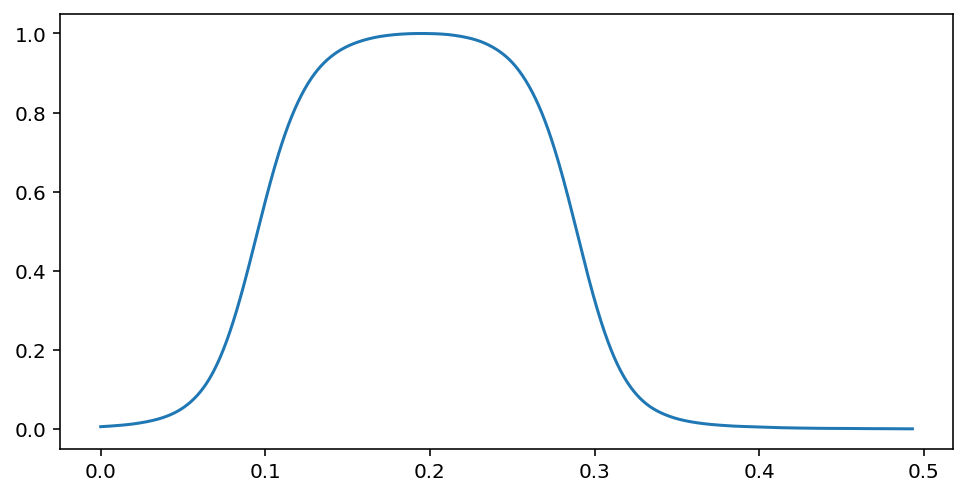

In [40]:
plt.plot(zlist, fieldlist)

In [41]:
# Effective length (integral of field^2)
Leff = np.trapz(fieldlist**2, zlist)/fieldlist.max()**2
Leff

0.16302677636670174

In [42]:
0.1/Leff

0.613396168584396

In [43]:
0.4*0.61339616

0.245358464

In [44]:
0.4*0.1/Leff

0.24535846743375844

In [45]:
0.4 /10

0.04

In [46]:
# PV (kG*m)/Leff*m * 0.1 T/kG = peak field in T

In [47]:
# Integrated field (approximate)
dz = zmax/1000
BL = np.sum(fieldlist)*dz  # T*m

# 
BL * 10 # T*m -> kG*m

1.944494711358167

In [48]:
# Factor to convert BL in kG*m to Bmax in T
1/(BL * 10 )

0.5142724195436521

# Corrector Quads

In [49]:
ele = I.ele['CQ01']
ele

{'description': 'name:CQ01',
 'original': '0.36 0 0 1 0.01601  0.0 0.210 0.0254 0.0 0.0 0.0 0.0 0 /!name:CQ01',
 'L': 0.36,
 'type': 'quadrupole',
 'zedge': 0.01601,
 'b1_gradient': 0.0,
 'L_effective': 0.21,
 'radius': 0.0254,
 'x_offset': 0.0,
 'y_offset': 0.0,
 'x_rotation': 0.0,
 'y_rotation': 0.0,
 'z_rotation': 0.0,
 's': 0.37601,
 'name': 'CQ01'}

In [50]:
I['CQ01:b1_gradient']

0.0

In [51]:
# Factor to convert kG to T/m
0.1/ele['L_effective'] 

0.4761904761904762